# Stock Price Prediction using Machine Learning (ML)

### Using scikit-learn library for ML

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from typing import Dict, Tuple, Any
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Function: Get Historical Data
def get_stock_data(ticker:str, start_date:str, end_date:str) -> Any:
    data = yf.download(ticker, start = start_date, end = end_date)
    return data

In [3]:
# Function: Feature Engineering

def engineer_features(data: pd.DataFrame) -> pd.DataFrame:
    df = data.copy()

    # Calculate daily return
    df['Return'] = df['Close'].pct_change()

    # Calculate moving averages
    df['SMA_5'] = df['Close'].rolling(window = 5).mean()
    df['SMA_10'] = df['Close'].rolling(window = 10).mean()

    # Calculate Volatility: 5 day standard deviation from closing prices
    df['Volatility_5'] = df['Close'].rolling(window=5).std()

    # Create lag features: Closing price from 1, 2, 3 days ago
    # If you increase lag features also update prepare data
    for i in range(1,4):
        df[f"Close_lag{i}"] = df["Close"].shift(i) # Shift function adds NaN to first row in Column Close_lag[i]
    
    
    # Target: This is what we want to predict: Tomorrow's closing price
    df['Target'] = df['Close'].shift(-1)

    print("\nProcessed Data:\n")
    print(df.head(15))

    # Remove rows with missing values
    df.dropna(inplace = True)

    return df
    

In [4]:
# Function Prepare data for modeling

def prepare_data(df:pd.DataFrame) -> Tuple[pd.DataFrame, pd.Series]:
    #Define a list of columns that are going to be forwarded to the ML model

    features = [
        'Close_lag1',
        'Close_lag2',
        'Close_lag3',
        'SMA_5',
        'SMA_10',
        'Volatility_5',
        'Return'
    ]

    X = df[features]
    y = df['Target']

    return X, y
        

In [5]:
# Splitting training and testing data
def train_test_split_ts(X: pd.DataFrame, y:pd.Series, split: float = 0.8) -> Tuple:
    split_idx = int(len(X) * split)

    return(
        X.iloc[:split_idx],
        X.iloc[split_idx:],
        y.iloc[:split_idx],
        y.iloc[split_idx:],
    )

In [6]:
# Model Training
def train_model(X_train: pd.DataFrame, y_train: pd.Series, model_type: str = "lr") -> Any:
    if model_type == "lr":
        model = LinearRegression()
    else:
        print("Model Type not available")
    model.fit(X_train, y_train)
    return model

In [7]:
# Model Evaluation:

def evaluate_model(model: Any, X_test: pd.DataFrame, y_test: pd.Series) -> Dict[str, float]:
    y_pred = model.predict(X_test)
    return {
        "mse": mean_squared_error(y_test, y_pred),
        "r2": r2_score(y_test, y_pred),
        "predictions": y_pred
    }

In [12]:
# Plot predictions

def plot_predictions(y_test: pd.Series, y_pred: np.ndarray, ticker: str, model_type: str):
    plt.figure(figsize = (12,6))
    plt.plot(y_test.index, y_test, label = "Actual Price", color = "blue")
    plt.plot(y_test.index, y_pred, label = "Predicted Price", color = "orange")
    plt.title(f"{ticker} Actual vs Predicted Prices ({model_type})")
    plt.xlabel("Date")
    plt.ylabel("Price ($)")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation = 45)
    plt.tight_layout()
    plt.show()

In [13]:
# Predict next day Price

def predict_next_day(model: Any, latest_data: pd.Series) -> float:
    features = [
        'Close_lag1',
        'Close_lag2',
        'Close_lag3',
        'SMA_5',
        'SMA_10',
        'Volatility_5',
        'Return'
    ]
    prediction_features = np.array([latest_data[f] for f in features]).reshape(1,-1)
    return model.predict(prediction_features)[0]

In [17]:
# Main Function

def main():
    start_date = "2020-02-07"
    end_date = "2025-02-07"
    stocks = ["TSLA", "META", "MA", "V", "NFLX", "AMZN", "GOOGL", "JPM", "MSFT"]
    prediction_date = "2025-02-10"

    results = {}

    for ticker in stocks: 
        print(f"\nProcessing {ticker}...")

        # 1. Get the data
        data = get_stock_data(ticker, start_date, end_date)

        # 2. Get features from the data
        processed_data = engineer_features(data)

        # 3. Prepare teh data for our model 
        X, y = prepare_data(processed_data)

        # 4. Split the data into testing and training. Note: we are not shuffling because it is a time series.
        X_train, X_test, y_train, y_test = train_test_split_ts(X, y)

        # 5. Training model
        models =  {
            "Linear Regression": train_model(X_train, y_train, model_type = "lr")
        }

        results[ticker] = {}
        for model_name, model in models.items():
            # 6. Evaluate model on test data
            eval_results = evaluate_model(model, X_test, y_test)
            # 7. Plot the Predictions vs actual prices
            plot_predictions(y_test, eval_results["predictions"], ticker, model_name)
            # 8. Predict next day price
            next_day_price = predict_next_day(model, processed_data.iloc[-1])
            results[ticker][model_name] = {
                "metrics": eval_results, 
                "prediction": next_day_price
            }
        print("\nPrediction Summary for", prediction_date)
        print("-"*50)
        for ticker, models in results.items():
            print(f"\n{ticker}:")
            for model_name, result in models.items():
                print(f" {model_name}")
                print(f" MSE: {result["metrics"]["mse"]:.2f}")
                print(f" R2: {result["metrics"]["r2"]:.2f}")
                print(f" Predicted Price: ${result['prediction']:.2f}")

[*********************100%***********************]  1 of 1 completed


Processing TSLA...

Processed Date:

Price           Close       High        Low       Open     Volume    Return  \
Ticker           TSLA       TSLA       TSLA       TSLA       TSLA             
Date                                                                          
2020-02-07  49.871334  51.316666  48.666668  48.703335  255952500       NaN   
2020-02-10  51.418667  54.666000  50.160000  53.333332  370338000  0.031026   
2020-02-11  51.625332  52.234001  50.533333  51.252666  175462500  0.004019   
2020-02-12  51.152668  52.650002  50.891335  51.858002  180337500 -0.009156   
2020-02-13  53.599998  54.533333  49.000000  49.456001  394339500  0.047844   
2020-02-14  53.335335  54.198002  52.366669  52.481335  235405500 -0.004938   
2020-02-18  57.226665  57.333332  55.490665  56.106667  245725500  0.072960   
2020-02-19  61.161331  62.985332  60.068001  61.566666  381345000  0.068756   
2020-02-20  59.960667  60.799999  57.329334  60.796665  264523500 -0.019631   
2020-02-21  60

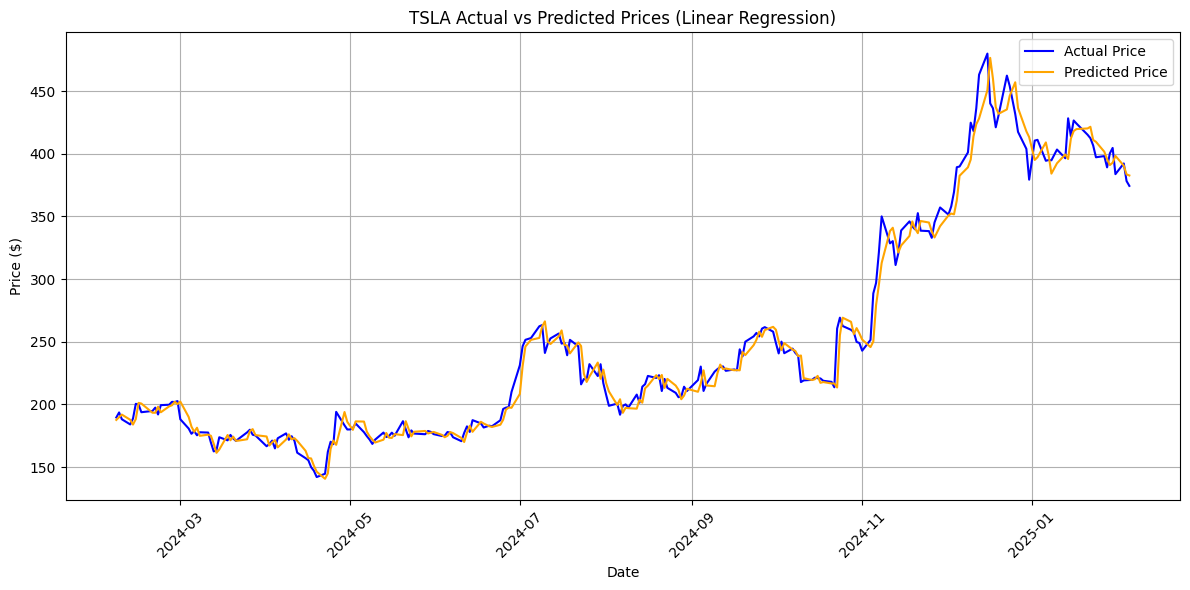

[*********************100%***********************]  1 of 1 completed


Prediction Summary for 2025-02-10
--------------------------------------------------

TSLA:
 Linear Regression
 MSE: 123.66
 R2: 0.98
 Predicted Price: $382.63

Processing META...

Processed Date:

Price            Close        High         Low        Open    Volume  \
Ticker            META        META        META        META      META   
Date                                                                   
2020-02-07  211.522003  212.010144  209.131127  209.499729  12242500   
2020-02-10  212.249207  212.986396  209.858346  210.715074  11856400   
2020-02-11  206.401566  210.057598  205.724145  209.390149  25030800   
2020-02-12  209.957977  210.416234  206.610763  207.059062  13813700   
2020-02-13  212.328918  213.514392  208.383981  208.722699  15396600   
2020-02-14  213.364944  214.112090  211.840768  213.185637  10741700   
2020-02-18  216.971191  217.150499  212.587926  212.737364  15609200   
2020-02-19  216.662369  217.489212  215.287615  217.160466  12135100   
2020-02-2

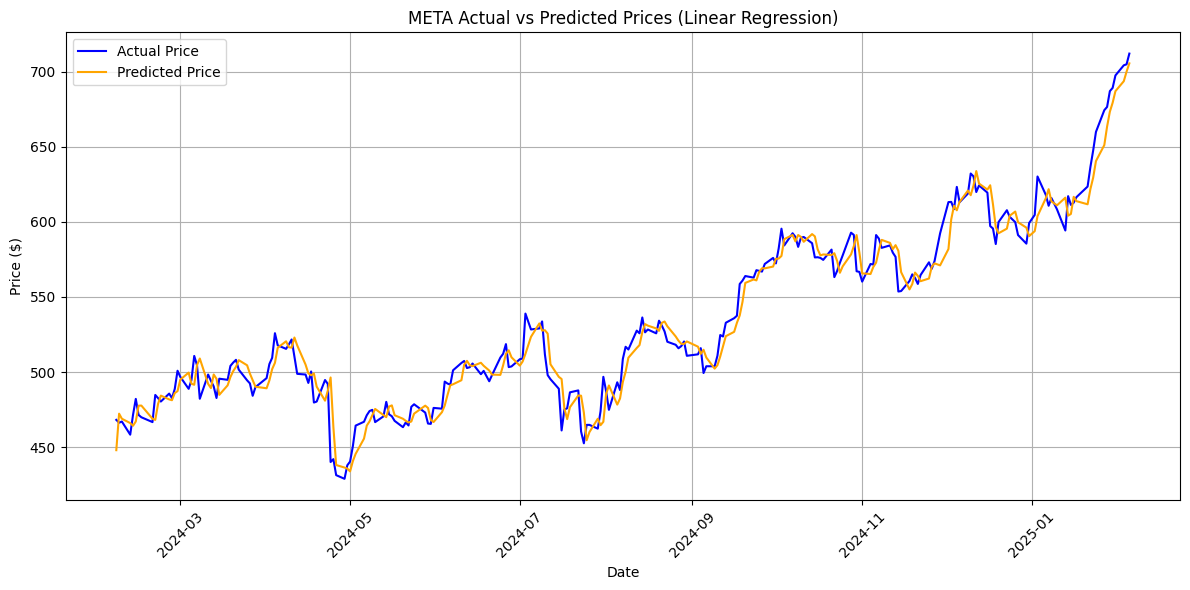

[*********************100%***********************]  1 of 1 completed


Prediction Summary for 2025-02-10
--------------------------------------------------

TSLA:
 Linear Regression
 MSE: 123.66
 R2: 0.98
 Predicted Price: $382.63

META:
 Linear Regression
 MSE: 128.69
 R2: 0.96
 Predicted Price: $705.47

Processing MA...

Processed Date:

Price            Close        High         Low        Open    Volume  \
Ticker              MA          MA          MA          MA        MA   
Date                                                                   
2020-02-07  317.938416  320.709444  316.839725  318.910704   2584200   
2020-02-10  321.127625  321.127625  316.489816  316.596754   3848100   
2020-02-11  321.749817  326.222322  320.524724  325.716742   3449300   
2020-02-12  324.900085  325.182058  320.096976  321.652644   2451000   
2020-02-13  326.533508  328.468354  322.926325  323.101330   3001000   
2020-02-14  331.501923  331.589425  327.690537  328.108614   2716300   
2020-02-18  331.783813  333.592286  330.957392  332.153288   3597300   
2020-02-

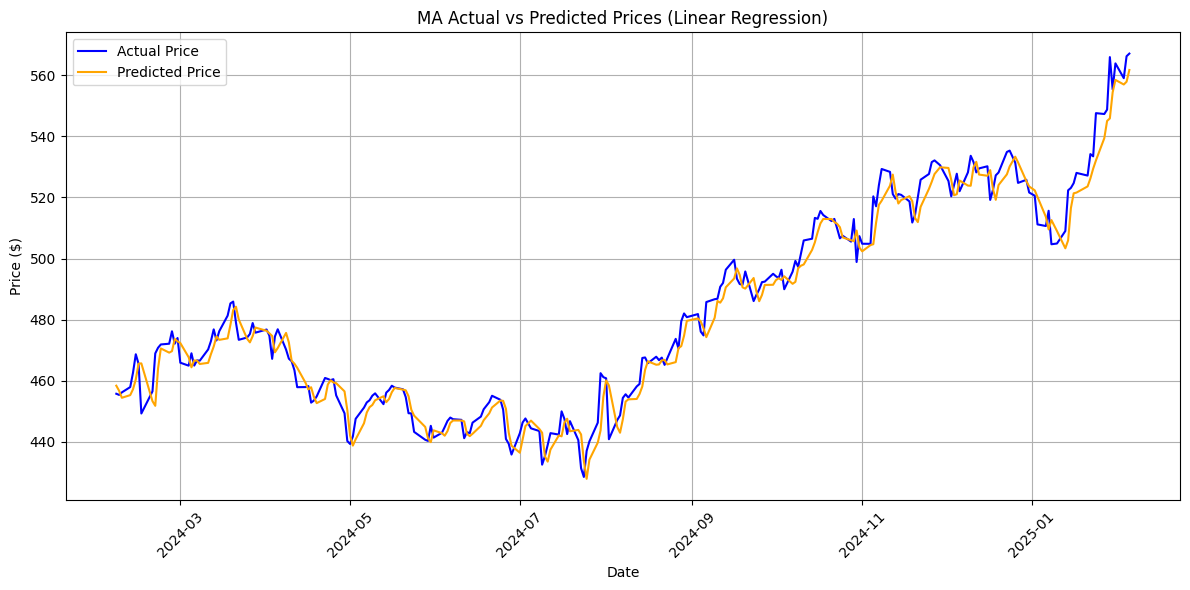

[*********************100%***********************]  1 of 1 completed


Prediction Summary for 2025-02-10
--------------------------------------------------

TSLA:
 Linear Regression
 MSE: 123.66
 R2: 0.98
 Predicted Price: $382.63

META:
 Linear Regression
 MSE: 128.69
 R2: 0.96
 Predicted Price: $705.47

MA:
 Linear Regression
 MSE: 31.34
 R2: 0.97
 Predicted Price: $561.79

Processing V...

Processed Date:

Price            Close        High         Low        Open    Volume  \
Ticker               V           V           V           V         V   
Date                                                                   
2020-02-07  195.375351  196.425753  193.785279  194.642949   5691100   
2020-02-10  198.507248  198.642162  194.527269  194.633274   6239500   
2020-02-11  196.531754  200.126255  196.242648  199.962432  10231900   
2020-02-12  199.904572  200.588772  197.553204  197.553204   7355800   
2020-02-13  200.155472  201.188104  198.852636  199.402719   9495300   
2020-02-14  202.944550  203.417439  200.744191  201.014410   6548800   
2020-02-1

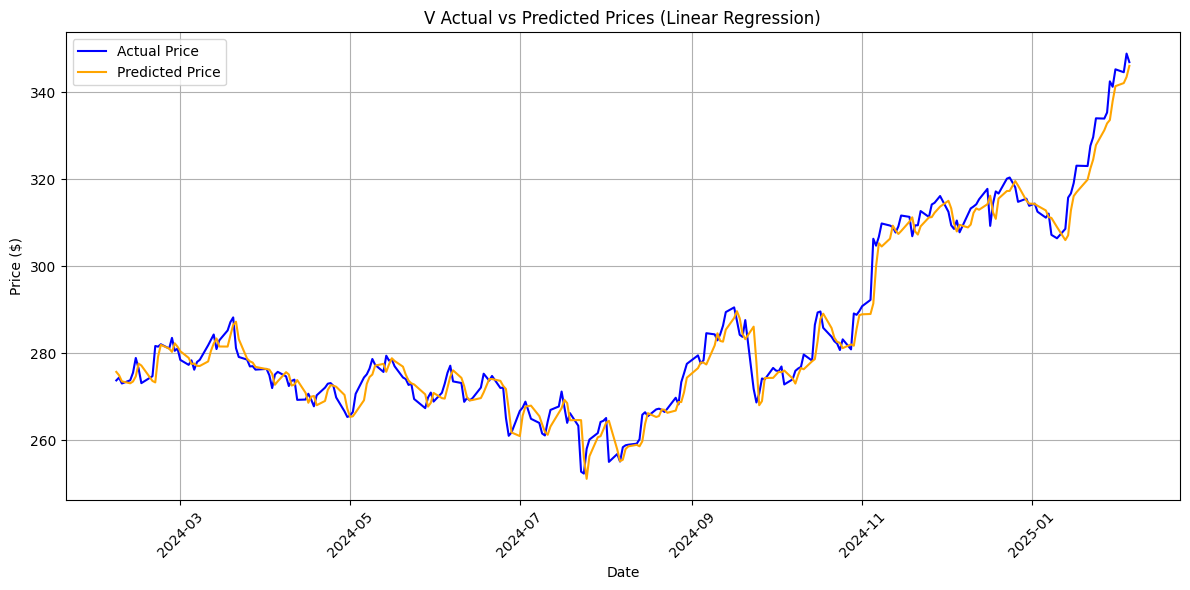

[*********************100%***********************]  1 of 1 completed


Prediction Summary for 2025-02-10
--------------------------------------------------

TSLA:
 Linear Regression
 MSE: 123.66
 R2: 0.98
 Predicted Price: $382.63

META:
 Linear Regression
 MSE: 128.69
 R2: 0.96
 Predicted Price: $705.47

MA:
 Linear Regression
 MSE: 31.34
 R2: 0.97
 Predicted Price: $561.79

V:
 Linear Regression
 MSE: 11.76
 R2: 0.97
 Predicted Price: $346.03

Processing NFLX...



Processed Date:

Price            Close        High         Low        Open    Volume  \
Ticker            NFLX        NFLX        NFLX        NFLX      NFLX   
Date                                                                   
2020-02-07  366.769989  371.799988  363.570007  365.040009   4385200   
2020-02-10  371.070007  374.799988  362.519989  365.000000   5294100   
2020-02-11  373.690002  378.109985  369.720001  373.750000   4772900   
2020-02-12  380.010010  380.619995  375.880005  377.179993   4624800   
2020-02-13  381.399994  385.369995  376.510010  376.959991   4485400   
2020-02-14  380.399994  385.149994  379.429993  381.470001   3736300   
2020-02-18  387.779999  389.540009  379.190002  379.299988   5173900   
2020-02-19  386.190002  392.950012  384.899994  388.119995   4896400   
2020-02-20  386.000000  389.700012  376.679993  386.559998   4079400   
2020-02-21  380.070007  387.320007  377.899994  385.329987   3930100   
2020-02-24  368.700012  372.820007  361.000000

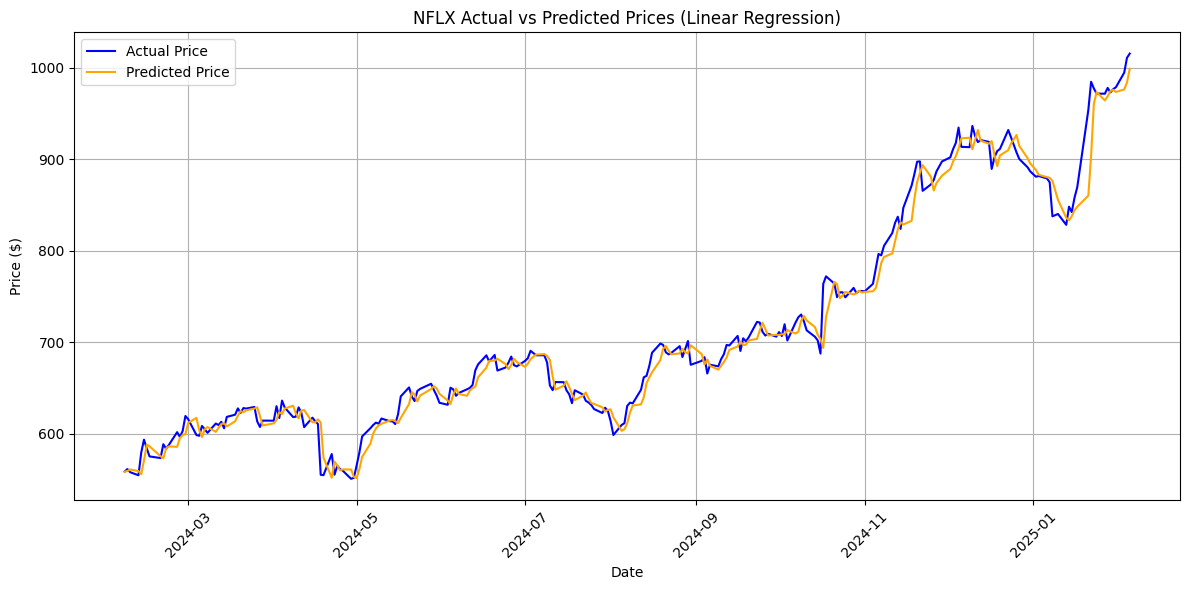

[*********************100%***********************]  1 of 1 completed


Prediction Summary for 2025-02-10
--------------------------------------------------

TSLA:
 Linear Regression
 MSE: 123.66
 R2: 0.98
 Predicted Price: $382.63

META:
 Linear Regression
 MSE: 128.69
 R2: 0.96
 Predicted Price: $705.47

MA:
 Linear Regression
 MSE: 31.34
 R2: 0.97
 Predicted Price: $561.79

V:
 Linear Regression
 MSE: 11.76
 R2: 0.97
 Predicted Price: $346.03

NFLX:
 Linear Regression
 MSE: 245.73
 R2: 0.98
 Predicted Price: $999.08

Processing AMZN...

Processed Date:

Price            Close        High         Low        Open     Volume  \
Ticker            AMZN        AMZN        AMZN        AMZN       AMZN   
Date                                                                    
2020-02-07  103.963997  104.926498  101.904999  102.099503  101906000   
2020-02-10  106.695503  106.779999  104.248001  104.250504  101124000   
2020-02-11  107.540001  109.297501  106.800003  107.544998  114920000   
2020-02-12  108.000000  109.012497  107.764503  108.160004   66686000 

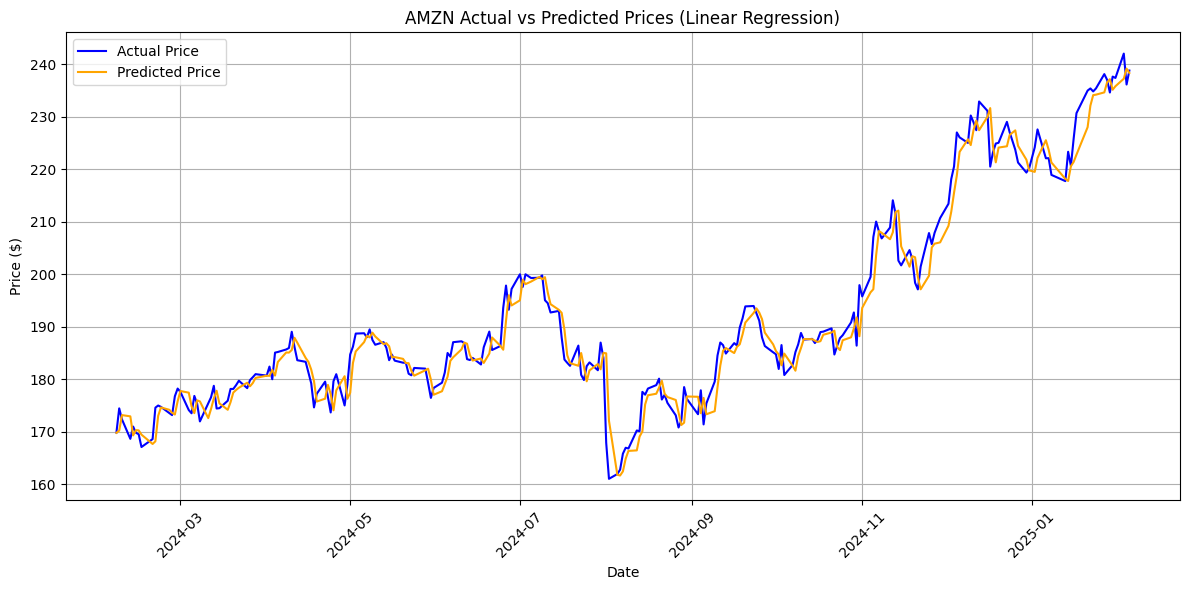

[*********************100%***********************]  1 of 1 completed


Prediction Summary for 2025-02-10
--------------------------------------------------

TSLA:
 Linear Regression
 MSE: 123.66
 R2: 0.98
 Predicted Price: $382.63

META:
 Linear Regression
 MSE: 128.69
 R2: 0.96
 Predicted Price: $705.47

MA:
 Linear Regression
 MSE: 31.34
 R2: 0.97
 Predicted Price: $561.79

V:
 Linear Regression
 MSE: 11.76
 R2: 0.97
 Predicted Price: $346.03

NFLX:
 Linear Regression
 MSE: 245.73
 R2: 0.98
 Predicted Price: $999.08

AMZN:
 Linear Regression
 MSE: 12.55
 R2: 0.97
 Predicted Price: $238.37

Processing GOOGL...



Processed Date:

Price           Close       High        Low       Open    Volume    Return  \
Ticker          GOOGL      GOOGL      GOOGL      GOOGL     GOOGL             
Date                                                                         
2020-02-07  73.603600  73.909138  72.921861  73.020389  28360000       NaN   
2020-02-10  75.074074  75.085023  73.409038  73.510056  38302000  0.019978   
2020-02-11  75.143738  76.130027  74.914335  75.303474  34852000  0.000928   
2020-02-12  75.570206  75.653304  75.074574  75.432361  31042000  0.005675   
2020-02-13  75.309456  75.934466  74.842185  75.140760  22914000 -0.003450   
2020-02-14  75.575172  75.640860  74.919304  75.366173  23198000  0.003528   
2020-02-18  75.610512  76.163866  75.191016  75.356728  25642000  0.000468   
2020-02-19  75.880714  76.172821  75.687144  75.996661  22746000  0.003574   
2020-02-20  75.488586  75.990186  74.855110  75.589104  25962000 -0.005168   
2020-02-21  73.820068  75.188032  73.572754  7

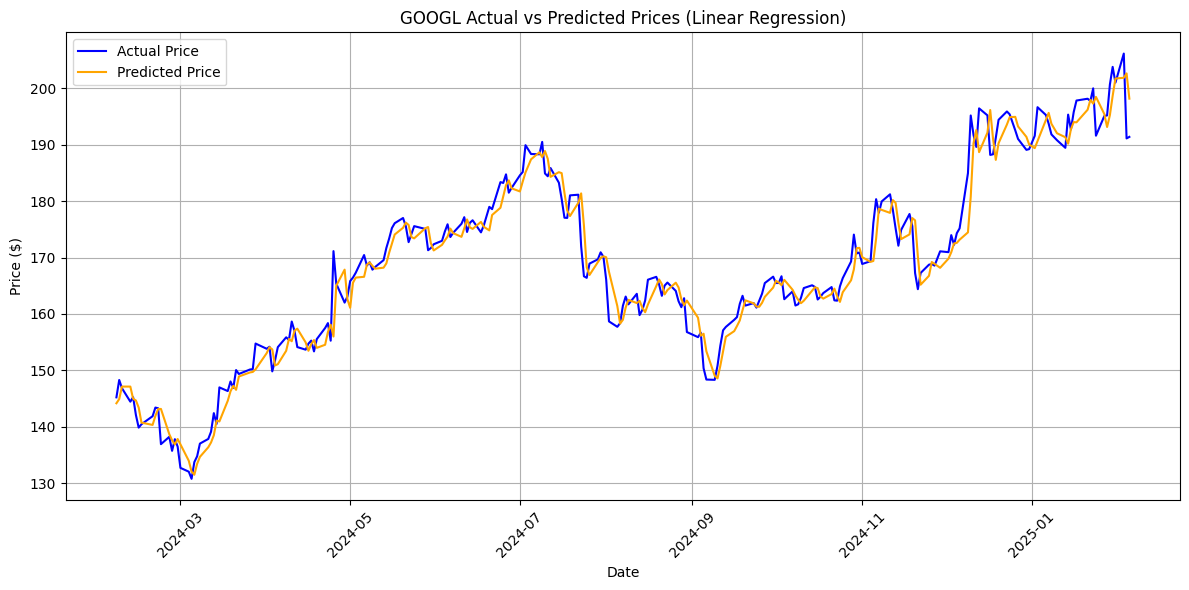

[*********************100%***********************]  1 of 1 completed


Prediction Summary for 2025-02-10
--------------------------------------------------

TSLA:
 Linear Regression
 MSE: 123.66
 R2: 0.98
 Predicted Price: $382.63

META:
 Linear Regression
 MSE: 128.69
 R2: 0.96
 Predicted Price: $705.47

MA:
 Linear Regression
 MSE: 31.34
 R2: 0.97
 Predicted Price: $561.79

V:
 Linear Regression
 MSE: 11.76
 R2: 0.97
 Predicted Price: $346.03

NFLX:
 Linear Regression
 MSE: 245.73
 R2: 0.98
 Predicted Price: $999.08

AMZN:
 Linear Regression
 MSE: 12.55
 R2: 0.97
 Predicted Price: $238.37

GOOGL:
 Linear Regression
 MSE: 11.12
 R2: 0.96
 Predicted Price: $198.16

Processing JPM...

Processed Date:

Price            Close        High         Low        Open    Volume  \
Ticker             JPM         JPM         JPM         JPM       JPM   
Date                                                                   
2020-02-07  118.860352  119.293611  118.106485  118.479081   6379800   
2020-02-10  119.354271  119.449589  118.496413  118.669714   5960700   


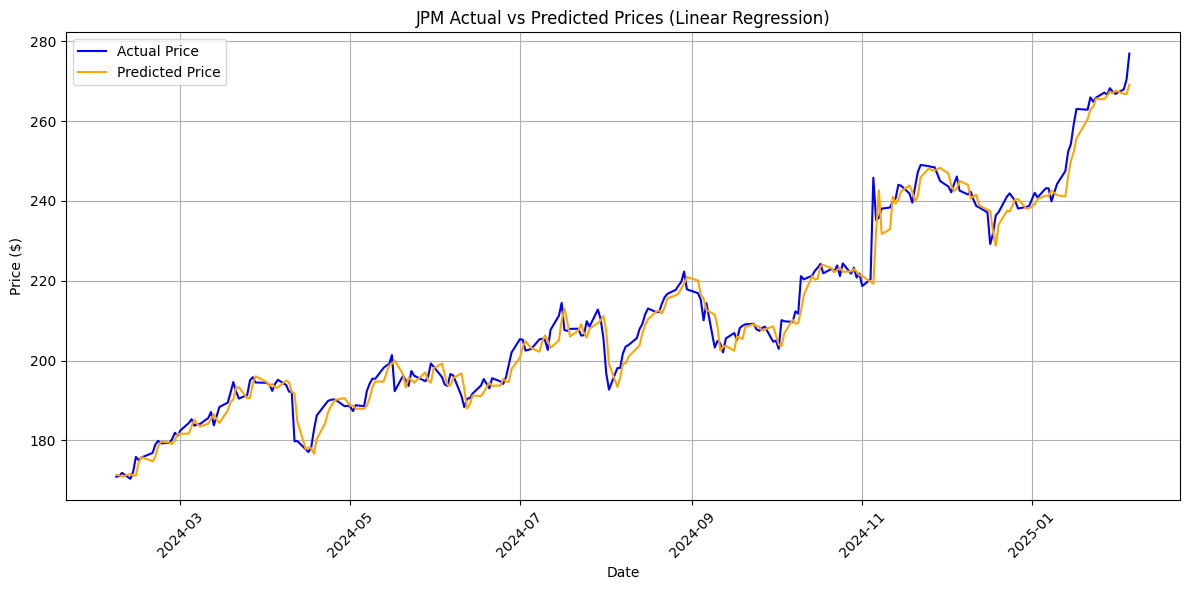

[*********************100%***********************]  1 of 1 completed


Prediction Summary for 2025-02-10
--------------------------------------------------

TSLA:
 Linear Regression
 MSE: 123.66
 R2: 0.98
 Predicted Price: $382.63

META:
 Linear Regression
 MSE: 128.69
 R2: 0.96
 Predicted Price: $705.47

MA:
 Linear Regression
 MSE: 31.34
 R2: 0.97
 Predicted Price: $561.79

V:
 Linear Regression
 MSE: 11.76
 R2: 0.97
 Predicted Price: $346.03

NFLX:
 Linear Regression
 MSE: 245.73
 R2: 0.98
 Predicted Price: $999.08

AMZN:
 Linear Regression
 MSE: 12.55
 R2: 0.97
 Predicted Price: $238.37

GOOGL:
 Linear Regression
 MSE: 11.12
 R2: 0.96
 Predicted Price: $198.16

JPM:
 Linear Regression
 MSE: 12.61
 R2: 0.98
 Predicted Price: $269.09

Processing MSFT...

Processed Date:

Price            Close        High         Low        Open    Volume  \
Ticker            MSFT        MSFT        MSFT        MSFT      MSFT   
Date                                                                   
2020-02-07  175.536148  177.197108  174.190199  174.543400  33529100  

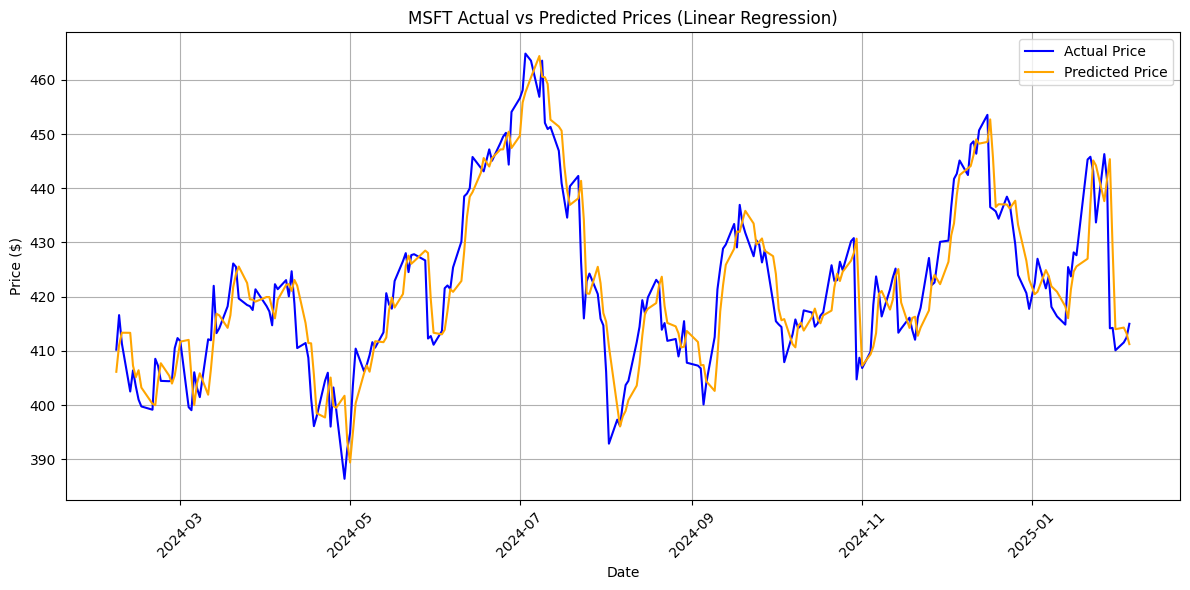


Prediction Summary for 2025-02-10
--------------------------------------------------

TSLA:
 Linear Regression
 MSE: 123.66
 R2: 0.98
 Predicted Price: $382.63

META:
 Linear Regression
 MSE: 128.69
 R2: 0.96
 Predicted Price: $705.47

MA:
 Linear Regression
 MSE: 31.34
 R2: 0.97
 Predicted Price: $561.79

V:
 Linear Regression
 MSE: 11.76
 R2: 0.97
 Predicted Price: $346.03

NFLX:
 Linear Regression
 MSE: 245.73
 R2: 0.98
 Predicted Price: $999.08

AMZN:
 Linear Regression
 MSE: 12.55
 R2: 0.97
 Predicted Price: $238.37

GOOGL:
 Linear Regression
 MSE: 11.12
 R2: 0.96
 Predicted Price: $198.16

JPM:
 Linear Regression
 MSE: 12.61
 R2: 0.98
 Predicted Price: $269.09

MSFT:
 Linear Regression
 MSE: 40.20
 R2: 0.82
 Predicted Price: $411.23


In [18]:
main()